In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/archive (1).zip"
extract_path = "/content/alzheimer"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed!")

Mounted at /content/drive
Extraction Completed!


In [ ]:
import cv2
import numpy as np
import os

X = []
y = []

dataset_path = "/content/alzheimer/Combined Dataset/train"

for category in os.listdir(dataset_path):

    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128,128))

            X.append(img.flatten())
            y.append(category)

        except:
            pass

print("Samples:", len(X))

Samples: 10240


In [ ]:
X = np.array(X)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)

['Mild Impairment' 'Moderate Impairment' 'No Impairment'
 'Very Mild Impairment']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import joblib

joblib.dump(model, "alzheimer_model.pkl")

['alzheimer_model.pkl']

In [ ]:
from google.colab import files

files.download("alzheimer_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print(image_path)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import cv2
import numpy as np

img = cv2.imread(image_path)
img = cv2.resize(img, (128,128))

img = img.flatten()

prediction = model.predict([img])

result = encoder.inverse_transform(prediction)

print("Predicted Class:", result[0])

Predicted Class: Very Mild Impairment


In [ ]:
probabilities = model.predict_proba([img])

confidence = np.max(probabilities) * 100

print(f"Confidence: {confidence:.2f}%")

Confidence: 54.00%


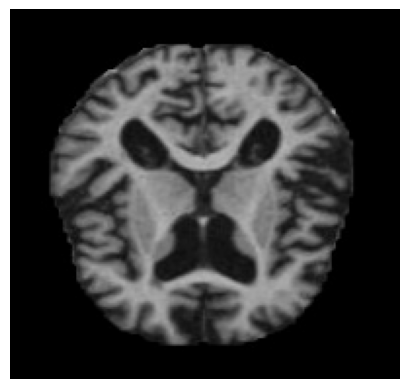

In [ ]:
import matplotlib.pyplot as plt

img_show = cv2.imread(image_path)
img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

plt.imshow(img_show)
plt.axis("off")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 95.068359375 %


In [ ]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.95068359375


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       512
           1       1.00      0.99      1.00       512
           2       0.88      0.98      0.93       512
           3       0.94      0.90      0.92       512

    accuracy                           0.95      2048
   macro avg       0.95      0.95      0.95      2048
weighted avg       0.95      0.95      0.95      2048



In [ ]:
import numpy as np

unique, counts = np.unique(pred, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(475), np.int64(1): np.int64(508), np.int64(2): np.int64(570), np.int64(3): np.int64(495)}


In [ ]:
print(encoder.classes_)

['Mild Impairment' 'Moderate Impairment' 'No Impairment'
 'Very Mild Impairment']
